<a href="https://colab.research.google.com/github/yanin-dev/ciencias_de_datos/blob/main/Csdatosparte_de_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerías para el análisis y transformación de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ruta_dataset = 'https://raw.githubusercontent.com/ros-arango/Datasets/refs/heads/main/el_mejor_(164_2024_30).csv'

# Carga del dataset.
dataset = pd.read_csv(ruta_dataset)

# Copia segura de trabajo.
df = dataset.copy()
df.head()

,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual
0,17.0,80.0,40.41476,-3.70418,4,157.0,5,173,0.93,17,342
1,17.0,66.0,40.42247,-3.70577,4,143.0,5,53,0.29,17,341
2,17.0,77.0,40.41884,-3.69655,3,65.0,1,249,2.78,3,299
3,17.0,66.0,40.42252,-3.70250,4,116.0,30,36,0.21,4,305
4,17.0,66.0,40.42252,-3.70250,4,79.0,30,31,0.18,4,317


✅ ¡Modelo entrenado y predicciones generadas con éxito!

--- 📊 REPORTE OFICIAL DE EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ---
• Coeficiente de Determinación (R² Score): 47.81% de la varianza explicada.
• Error Absoluto Medio (MAE): 22.27 € por noche en promedio.
• Raíz del Error Cuadrático Medio (RMSE): 27.58 € de desviación cuadrática.
---------------------------------------------------------------------------



Text(320, 30, 'Métricas de Evaluación:\nR²: 47.81%\nMAE: 22.27 €\nRMSE: 27.58 €')

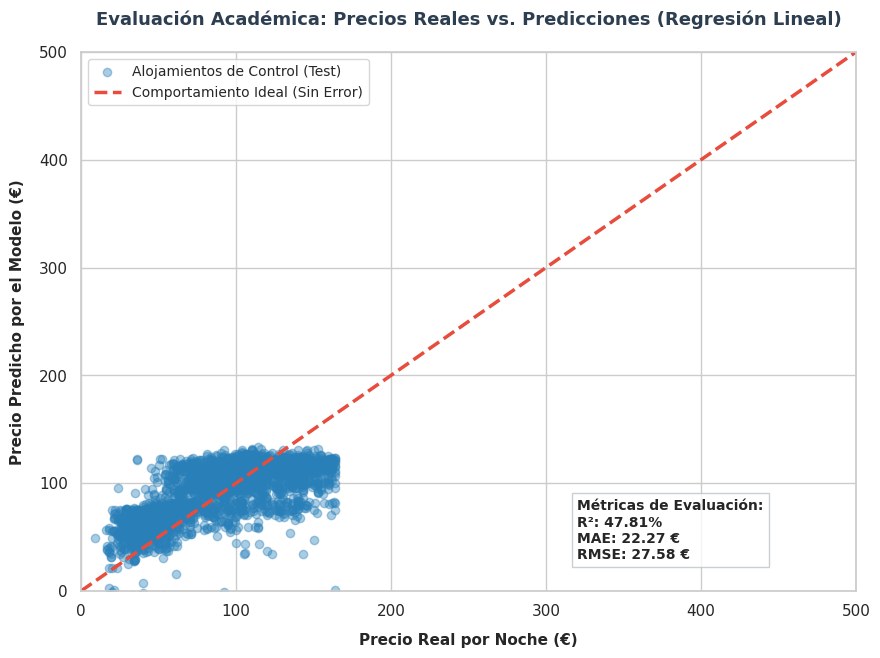

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. CARGA Y PREPARACIÓN DE MATRICES
# =====================================================================
# Cargamos el dataset limpio y optimizado para Madrid
df_madrid = pd.read_csv(ruta_dataset)

# 'precio' es la variable que el modelo debe aprender a predecir (precio por noche en €).
y = df_madrid['precio']

# Después definimos las features, que son las variables que utilizamos para realizar la predicción.Para ello tomamos todas las columnas del dataset excepto la columna precio.Además utilizamos One-Hot Encoding para convertir variables categóricas en valores numéricos que el algoritmo pueda interpretar.
X = pd.get_dummies(df_madrid.drop(columns=['precio']), drop_first=True)

# =====================================================================
# 2. ENTRENAMIENTO DE UN MODELO DE REGRESIÓN (Métricas Estándar)
# =====================================================================
# Separamos en 80% entrenamiento (permite que el modelo aprenda patrones)) y 20% prueba (sirve para verificar qué tan bien funciona con datos que nunca vio antes.)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("=======================================================================")
# --- ENTRENAMIENTO DEL MODELO DE REGRESIÓN ---
# Regresión Lineal Múltiple: aprende una ecuación lineal que combina todas las
# features para predecir el precio.
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)  # El algoritmo calcula la ecuación matemática del hiperplano

# Generamos las predicciones sobre el 20% de datos reservados para la evaluación
preds_lineal = modelo_lineal.predict(X_test)
print("✅ ¡Modelo entrenado y predicciones generadas con éxito!")
print("=======================================================================\n")

# =====================================================================
# 3. EVALUACIÓN CON MÉTRICAS ESTÁNDAR (R², MAE/RMSE)
# =====================================================================
# evaluamos el rendimiento utilizando tres métricas.
r2_lineal = r2_score(y_test, preds_lineal)
mae_lineal = mean_absolute_error(y_test, preds_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, preds_lineal))

print("--- 📊 REPORTE OFICIAL DE EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ---")
print(f"• Coeficiente de Determinación (R² Score): {r2_lineal * 100:.2f}% de la varianza explicada.")
print(f"• Error Absoluto Medio (MAE): {mae_lineal:.2f} € por noche en promedio.")
print(f"• Raíz del Error Cuadrático Medio (RMSE): {rmse_lineal:.2f} € de desviación cuadrática.")
print("-" * 75 + "\n")

# =====================================================================
# 4. VISUALIZACIONES CLARAS Y ETIQUETADAS (Diagnóstico: Real vs. Predicho)
# =====================================================================
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Dibujamos los puntos con un color azul  y transparencia para densidades
plt.scatter(y_test, preds_lineal, alpha=0.4, color='#2980b9', label='Alojamientos de Control (Test)')

# Línea de referencia ideal (Predicción perfecta Y = Ŷ)
plt.plot([0, 500], [0, 500], color='#e74c3c', linestyle='--', linewidth=2.5, label='Comportamiento Ideal (Sin Error)')

# Ajustes de formato y etiquetado profesional según la rúbrica
plt.title('Evaluación Académica: Precios Reales vs. Predicciones (Regresión Lineal)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Precio Real por Noche (€)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Precio Predicho por el Modelo (€)', fontsize=11, fontweight='bold', labelpad=10)

# Fijamos los límites comerciales (0 a 500€) para evitar deformaciones por outliers extremos
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.legend(loc='upper left', fontsize=10)

# Cuadro de texto incrustado con el reporte de métricas dentro del gráfico
texto_grafico = f"Métricas de Evaluación:\nR²: {r2_lineal*100:.2f}%\nMAE: {mae_lineal:.2f} €\nRMSE: {rmse_lineal:.2f} €"
plt.text(320, 30, texto_grafico, fontsize=10, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

Se uso una Regresión Lineal porque el objetivo era predecir un valor numérico continuo, que en este caso es el precio.

Coeficiente de Determinación ($R^2$ Score - 47.81%): el modelo logra explicar aproximadamente el 48% de las variaciones del precio de los alojamientos.

Error Absoluto Medio (MAE - 22.27 €): Esto indica que, en promedio, nuestras predicciones se equivocan unos 22 euros respecto al precio real.

Raíz del Error Cuadrático Medio (RMSE - 27.58 €): Esta métrica penaliza más los errores grandes, por lo que nos ayuda a detectar predicciones muy alejadas de la realidad.

Interpretación del gráfico:
El gráfico compara los precios reales de los alojamientos con los precios predichos por el modelo. La línea roja representa la predicción ideal,observamos que muchos puntos se encuentran relativamente cerca de la línea, lo que indica que el modelo logró captar parte de los patrones de los datos.

Sin embargo, también vemos dispersión, es decir, varios puntos alejados de la línea. Esto muestra que existen diferencias entre los valores reales y los predichos.

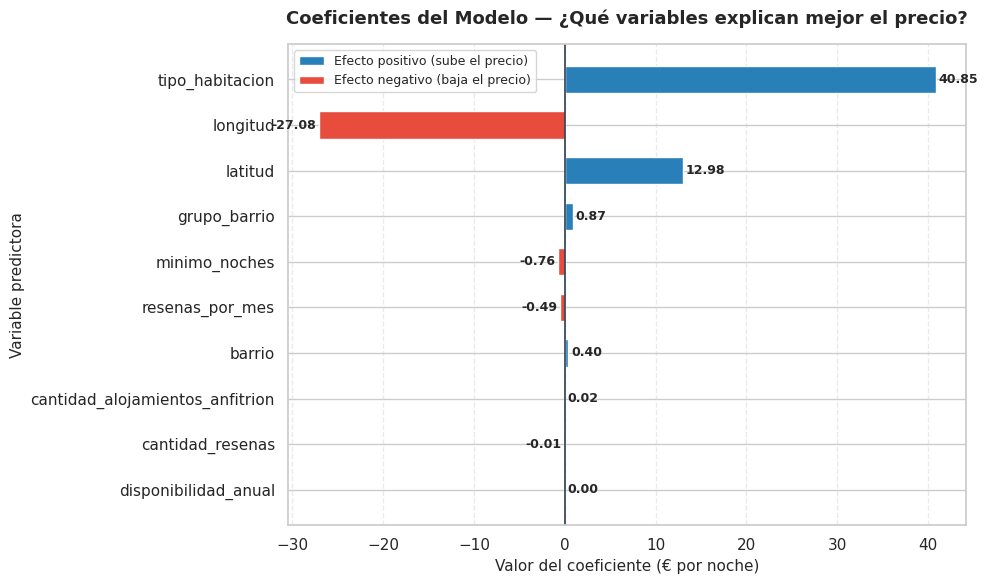

In [4]:
# =====================================================================
# 5. VISUALIZACIÓN: COEFICIENTES DEL MODELO
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Extraemos los coeficientes del modelo: indican cuánto cambia el precio (en €)
# por cada unidad que aumenta esa variable, manteniendo las demás constantes.
coef_df = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo_lineal.coef_
}).sort_values('coeficiente', key=abs, ascending=True)

colores = ['#2980b9' if c >= 0 else '#e74c3c' for c in coef_df['coeficiente']]

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['variable'], coef_df['coeficiente'],
                color=colores, edgecolor='white', height=0.6)

plt.axvline(0, color='#2c3e50', linewidth=1.2)
plt.title('Coeficientes del Modelo — ¿Qué variables explican mejor el precio?',
          fontsize=13, fontweight='bold', pad=14)
plt.xlabel('Valor del coeficiente (€ por noche)', fontsize=11)
plt.ylabel('Variable predictora', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)

for bar, val in zip(bars, coef_df['coeficiente']):
    plt.text(val + (0.3 if val >= 0 else -0.3),
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='#2980b9', label='Efecto positivo (sube el precio)'),
    Patch(facecolor='#e74c3c', label='Efecto negativo (baja el precio)')
], fontsize=9)

plt.tight_layout()
plt.show()

## Interpretación de coeficientes

El tipo de habitación es la variable con mayor impacto (+40.85 €):
a mayor exclusividad del alojamiento, mayor es el precio.
La ubicación geográfica (latitud y longitud) también influye
significativamente, reflejando que los barrios céntricos de Madrid
concentran los precios más altos.
Variables como cantidad de reseñas o disponibilidad anual
tienen un efecto casi nulo sobre el precio.